# Targeted Password Guessing with Beam Search and Batch Inference

Targeted password guessing using a fine‑tuned PassLLM (Qwen2.5‑0.5B + adapter).  

For each old password from the Kaggle test set, we generate **100 candidate new passwords** using **dynamic beam search**.


## Install dependencies

In [10]:
!python --version

Python 3.12.3


In [ ]:
!pip install -q transformers peft accelerate pandas matplotlib tqdm

In [ ]:
!pip install kaggle
!apt-get update && apt-get install -y unzip

## Download competition data from Kaggle

Upload your `kaggle.json` API token when prompted.

In [12]:
import os
import sys


kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
src_config = 'kaggle.json'
dst_config = os.path.join(kaggle_dir, 'kaggle.json')

if os.path.exists(src_config):
    import shutil
    if os.path.abspath(src_config) != os.path.abspath(dst_config):
        shutil.copy(src_config, dst_config)

    if os.name != 'nt':
        os.chmod(dst_config, 0o600)
    print("Ok")
else:
    print('Error')


Ok


Make a content directory to process the data in Colab way.

In [10]:
!mkdir -p /content/data
!chmod 777 /content/data

In [14]:
!kaggle competitions download -c password-guessing -p /content/data
!unzip -q /content/data/password-guessing.zip -d /content/data
!ls /content/data

100%|██████████████████████████████████████| 62.8M/62.8M [00:07<00:00, 9.33MB/s]

126_csdn_disQwen0.5B   rockyou_100w_disQwen0.5B  test.json
new_train.json	       sample_submission.csv	 train.json
password-guessing.zip  submission_promt.txt


## Environment setup and constants

The `rockyou_100w_disQwen0.5B` model was trained on English passwords and merely generates popular variants without taking the old password into consideration. `126_csdn_disQwen0.5B` was trained on Chinese data, so it tends to generate Chinese subwords like "wang", but it copes better with the old password and is more capable of creating modifications to old passwords.

In [13]:
import os
import json
import torch
import random
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

COMPETITION = "/content/data"
PATH_TRAIN = os.path.join(COMPETITION, "new_train.json")
PATH_TEST  = os.path.join(COMPETITION, "test.json")
PATH_ADAPTER = os.path.join(COMPETITION, "126_csdn_disQwen0.5B", "126_csdn_disQwen0.5B")
BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print("COMPETITION:", COMPETITION)
print("PATH_TRAIN:", PATH_TRAIN)
print("PATH_ADAPTER:", PATH_ADAPTER)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"Device: {device_name}")

COMPETITION: /content/data
PATH_TRAIN: /content/data/new_train.json
PATH_ADAPTER: /content/data/126_csdn_disQwen0.5B/126_csdn_disQwen0.5B
Device: NVIDIA GeForce RTX 5090


In [14]:
with open(PATH_TRAIN, "r", encoding="utf-8") as f:
    TRAIN_DATA = json.load(f)
if isinstance(TRAIN_DATA, dict):
    TRAIN_DATA = [TRAIN_DATA]
print("Train samples:", len(TRAIN_DATA))
if TRAIN_DATA:
    print("Example:", TRAIN_DATA[0])

Train samples: 16000
Example: {'Knowledge': {'Old password': 'AD2351597531'}, 'password': 'VIN_092000'}


## Password length distribution

Total passwords: 16000
Mean length: 9.86
Std dev: 3.14
1 sigma interval: [6.72, 13.00]
2 sigma interval: [3.58, 16.14]


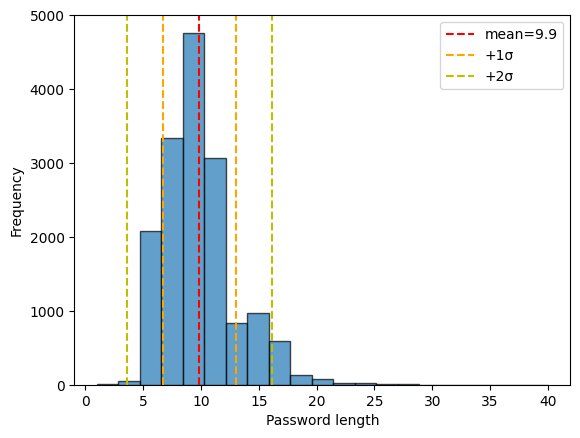

In [15]:
import numpy as np
import matplotlib.pyplot as plt

lengths = []
for item in TRAIN_DATA:
    pwd = item.get("password")
    if pwd and isinstance(pwd, str):
        lengths.append(len(pwd))

lengths = np.array(lengths)
mean = np.mean(lengths)
std = np.std(lengths)

print(f"Total passwords: {len(lengths)}")
print(f"Mean length: {mean:.2f}")
print(f"Std dev: {std:.2f}")
print(f"1 sigma interval: [{mean-std:.2f}, {mean+std:.2f}]")
print(f"2 sigma interval: [{mean-2*std:.2f}, {mean+2*std:.2f}]")

plt.hist(lengths, bins=21, alpha=0.7, edgecolor='black')
plt.axvline(mean, color='r', linestyle='dashed', label=f'mean={mean:.1f}')
plt.axvline(mean+std, color='orange', linestyle='dashed', label='+1σ')
plt.axvline(mean-std, color='orange', linestyle='dashed')
plt.axvline(mean+2*std, color='y', linestyle='dashed', label='+2σ')
plt.axvline(mean-2*std, color='y', linestyle='dashed')
plt.xlabel("Password length")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Load the PassLLM model

In [16]:
def load_passllm_model():
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    tokenizer.pad_token_id = tokenizer.eos_token_id
    tokenizer.padding_side = "left" 

    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        device_map="auto",
        torch_dtype=torch.bfloat16,
        trust_remote_code=True
    )

    if os.path.exists(PATH_ADAPTER):
        print(f"[INFO] Loading adapter from {PATH_ADAPTER}")
        model = PeftModel.from_pretrained(model, PATH_ADAPTER, is_trainable=False)
        model = model.merge_and_unload()
        print("[INFO] Adapter loaded and merged.")
    else:
        print(f"[WARNING] Adapter not found: {PATH_ADAPTER}")

    model.eval()
    return model, tokenizer

model, tokenizer = load_passllm_model()
print("Model loaded. Device:", model.device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[INFO] Loading adapter from /content/data/126_csdn_disQwen0.5B/126_csdn_disQwen0.5B
[INFO] Adapter loaded and merged.
Model loaded. Device: cuda:0


# Dynamic beam‑search generator for a single sample

We replicate the beam‑search logic from the [PassLLM paper](https://www.usenix.org/conference/usenixsecurity25/presentation/zou-yunkai): it starts with `beam_size = target_count` and doubles it until enough unique candidates are obtained.

In [13]:
def generate_passwords_beam_search(
    old_password: str,
    prompt_template: str,
    model,
    tokenizer,
    target_count: int = 100,
    max_new_tokens: int = 32,
    max_beam_size: int = 200,
    verbose: bool = False
):
    knowledge = json.dumps({"Old password": old_password})
    full_input = prompt_template.strip() + "\n" + knowledge + "\nPassword:"
    inputs = tokenizer(
        full_input, return_tensors="pt", truncation=True,
        max_length=512, padding_side='left'
    ).to(model.device)

    unique_candidates = []
    seen = set()
    beam_size = target_count

    while len(unique_candidates) < target_count and beam_size <= max_beam_size:
        if verbose:
            print(f"  Trying beam_size={beam_size} ...")

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                num_beams=beam_size,
                num_return_sequences=beam_size,
                early_stopping=True,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        for out in outputs:
            generated_text = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            guess = generated_text.split("\n")[0].strip()
            if guess.lower().startswith("password:"):
                guess = guess[9:].strip()
            if guess and guess not in seen:
                seen.add(guess)
                unique_candidates.append(guess)
                if len(unique_candidates) >= target_count:
                    break

        beam_size *= 2

    if len(unique_candidates) < target_count:
        chars = string.ascii_letters + string.digits + "!@#$%&*"
        while len(unique_candidates) < target_count:
            suffix = "".join(random.choices(chars, k=1))
            guess = old_password + suffix
            if guess not in seen:
                seen.add(guess)
                unique_candidates.append(guess)

    return unique_candidates[:target_count]

# Batched beam‑search for efficient inference

We define a custom `Dataset` and `collate_fn` to feed multiple prompts simultaneously. The batched generator processes several old passwords in one forward pass, significantly reducing total runtime.

In [17]:
class PasswordDataset(Dataset):
    def __init__(self, old_passwords, prompt_template, tokenizer):
        self.old_passwords = old_passwords
        self.prompt_template = prompt_template
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.old_passwords)

    def __getitem__(self, idx):
        old_pwd = self.old_passwords[idx]
        knowledge = json.dumps({"Old password": old_pwd})
        full_input = self.prompt_template.strip() + "\n" + knowledge + "\nPassword:"
        encoding = self.tokenizer(
            full_input,
            truncation=True,
            max_length=512,
            padding=False,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "old_password": old_pwd,
            "idx": idx
        }

def collate_fn(batch):
    input_ids = [item["input_ids"] for item in batch]
    attention_masks = [item["attention_mask"] for item in batch]
    old_passwords = [item["old_password"] for item in batch]
    indices = [item["idx"] for item in batch]

    padded = tokenizer.pad(
        {"input_ids": input_ids, "attention_mask": attention_masks},
        padding=True,
        return_tensors="pt"
    )
    return {
        "input_ids": padded["input_ids"],
        "attention_mask": padded["attention_mask"],
        "old_passwords": old_passwords,
        "indices": indices
    }

def generate_batch_beam_search(model, tokenizer, batch, prompt_template,
                               target_count=100, max_beam_size=200, max_new_tokens=32):
    input_ids = batch["input_ids"].to(model.device)
    attention_mask = batch["attention_mask"].to(model.device)
    batch_size = input_ids.size(0)

    all_candidates = [[] for _ in range(batch_size)]
    beam_size = target_count
    unique_counts = np.zeros(batch_size, dtype=np.int32)
    seen_sets = [set() for _ in range(batch_size)]
    old_passwords = batch["old_passwords"]

    while np.min(unique_counts) < target_count and beam_size <= max_beam_size:
        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                num_beams=beam_size,
                num_return_sequences=beam_size,
                early_stopping=True,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        for i in range(batch_size):
            start_idx = i * beam_size
            end_idx = (i + 1) * beam_size
            batch_outputs = outputs[start_idx:end_idx]

            for out in batch_outputs:
                generated_text = tokenizer.decode(out[input_ids[i].shape[0]:], skip_special_tokens=True)
                guess = generated_text.split("\n")[0].strip()
                if guess.lower().startswith("password:"):
                    guess = guess[9:].strip()
                if guess and guess not in seen_sets[i]:
                    seen_sets[i].add(guess)
                    all_candidates[i].append(guess)
                    if len(all_candidates[i]) >= target_count:
                        break
            unique_counts[i] = len(all_candidates[i])

        beam_size *= 2

    chars = np.array(list(string.ascii_letters + string.digits + "!@#$%&*"))
    for i in range(batch_size):
        if len(all_candidates[i]) < target_count:
            needed = target_count - len(all_candidates[i])
            while needed > 0:
                suffixes = np.random.choice(chars, size=(needed * 2, 1)).reshape(-1, 1)
                guesses = np.char.add(old_passwords[i], suffixes.flatten())
                for g in guesses:
                    if g not in seen_sets[i]:
                        seen_sets[i].add(g)
                        all_candidates[i].append(g)
                        needed -= 1
                        if needed == 0:
                            break
        else:
            all_candidates[i] = all_candidates[i][:target_count]

    return all_candidates, batch["indices"]

# Prompt Template

This prompt was manually tuned and later refined with DeepSeek.


In [18]:
PROMPT_TEMPLATE = """You are a targeted password guessing model. Your task: given an old password, generate a single realistic new password that a human might choose.

Consider the following common human password creation patterns:
- Length 6—12 characters, most often 9, shorter or longer (4–20).
- Mix of lowercase, uppercase, digits, and symbols (!@#$%&*).
- Leet substitutions: P@ssw0rd, Tr0ub4dor, 5ecr3t, L3tme1n, G0Dzilla.
- Dates: MMDDYYYY, DDMMYYYY, YYYYMMDD, MMDDYY, YYMMDD (with or without separators), years 1970-2005, 2020-2024, repeating years (1111,2222).
- Names: common first/last names, pet names, nicknames.
- Keyboard walks: horizontal (asdf, zxcv), diagonal (qweasd, 1qaz2wsx), spatial repeats (jjjj, kkkk).
- Base words: password, pass, admin, welcome, login, user, account, master, shadow, super, access.
- Number patterns: 123456, 654321, 1111, 9999, 0000, 1313, 6969.
- Frequent combinations: Word+Number (Apple123), Word+Symbol+Number (Sony#88), Name+BirthYear (Jessica1987), Word+Leet+Date (P@ss1990), KeyboardPattern+Number (qwerty123).
- Cultural references: games (Minecraft, Fortnite), movies (StarWars, Avengers), sports (Lakers, United), music (Beatles, Metallica).
- Character addition: prepend or append one character (e.g., 'a' + old password, old password + '!').

Example: Old password "password123" -> New password "P@ssw0rd2024"

Now, generate the new password. Output **only** the password string. Do not include any explanations, notes, or extra text. Just the password."""


## Train evaluation

Check on a single sample. We've manually verified by submitting that the test set doesn't contain passwords for which the new password is equal to the old (there are only 3 such cases), so we don't manually add it and truly generate 100 variants.

In [ ]:
test_old = "password1234"
candidates = generate_passwords_beam_search(
    test_old, PROMPT_TEMPLATE, model, tokenizer,
    target_count=100, verbose=True, max_beam_size=200,
)
print(f"Generated {len(candidates)} candidates:", candidates)

  Trying beam_size=100 ...
  Trying beam_size=200 ...
Generated 100 candidates: ['123456789', 'passw0rd', 'passw0rd123', 'a123456789', 'password123', '1234567890', 'apple123', 'pasw0rd2024', 'Passw0rd', '123123123', '12345678', 'password', 'passw0rd2024', 'PAsw0rd2024', 'a1234567890', 'asdf1234', 'passw0rd520', 'Passw0rd123', 'pasword2024', 'apple1234', '11111111', 'pasw0rd1234', '1111111111', 'asdfghjklmn', 'Password123', 'asdf123456', 'passw0rd007', '00000000', '111111111', 'passwor1234', 'Passw0rd2024', '11112222333', 'password520', '123456789a', 'passw0rd321', 'asd123456', 'pasword1234', 'passw0rd888', 'abc123456', 'passw0rd88', 'passw0rd000', '0000000000', 'password007', '11111111111', 'zxcvbnm1234', 'passw0rd001', '987654321', 'PAssw0rd', 'qweasd1234', '123456789.', 'abcd1234', '9876543210', 'admin123', '123456789A', 'woaini1234', 'pass1234', 'admin1234', 'a12345678', 'passw1234', 'woaini123', '88888888', '99999999', '000000000', '999999999', 'Password', 'apple2024', 'qweasdzxc',

In [19]:
torch.cuda.empty_cache()

Test with 100 samples from the train set.

In [ ]:
import torch
import json
from tqdm import tqdm

with open(PATH_TRAIN, "r", encoding="utf-8") as f:
    train_data = json.load(f)
if isinstance(train_data, dict):
    train_data = [train_data]

valid_items = []
for item in train_data:
    old = (item.get("Knowledge") or {}).get("Old password")
    target = item.get("password")
    if old and target:
        valid_items.append(item)

Load the train examples.

In [ ]:
sample_size = 100
indices = torch.randperm(len(valid_items))[:sample_size].tolist()
sample_items = [valid_items[i] for i in indices]

sample_old_passwords = [(item.get("Knowledge") or {}).get("Old password") for item in sample_items]
sample_targets = [item.get("password") for item in sample_items]

dataset = PasswordDataset(sample_old_passwords, PROMPT_TEMPLATE, tokenizer)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [ ]:
predictions = []
correct = 0
total = 0

for batch in tqdm(dataloader, desc="Evaluating on train sample"):
    batch_candidates, indices = generate_batch_beam_search(
        model, tokenizer, batch, PROMPT_TEMPLATE,
        target_count=100, max_beam_size=200
    )
    for i, idx in enumerate(indices):
        old = sample_old_passwords[idx]
        target = sample_targets[idx]
        candidates = batch_candidates[i]
        is_correct = target in candidates
        if is_correct:
            correct += 1
        total += 1
        predictions.append({
            "old": old,
            "target": target,
            "candidates": candidates[:100],
            "correct": is_correct
        })
    print(batch_candidates)

crack_rate = correct / total if total > 0 else 0.0
print(f"Crack rate on {total} samples: {crack_rate:.4f} ({crack_rate*100:.2f}%)")

In [31]:
with open("train_predictions.json", "w") as f:
    json.dump(predictions, f, indent=2)
print("Saved predictions to train_predictions.json")

Saved predictions to train_predictions.json


## Final inference on test set and Kaggle submission

In [20]:
with open(PATH_TEST, "r") as f:
    test_data = json.load(f)
old_passwords = [item["Knowledge"]["Old password"] for item in test_data]
print(f"Test samples: {len(old_passwords)}")

dataset = PasswordDataset(old_passwords, PROMPT_TEMPLATE, tokenizer)
dataloader = DataLoader(
    dataset,
    batch_size=5,
    shuffle=False,
    collate_fn=collate_fn
)


Test samples: 8000


In [21]:
import torch
import subprocess
import string
from tqdm import tqdm

def get_vram_usage():
    out = subprocess.check_output([
        "nvidia-smi",
        "--query-gpu=memory.used,memory.total",
        "--format=csv,nounits,noheader"
    ]).decode().strip()
    used, total = map(int, out.split(","))
    return used / total * 100

all_guesses_dict = {}
chars = string.ascii_letters + string.digits + "!@#$%&*"

for step, batch in enumerate(tqdm(dataloader, desc="Generating batches")):
    batch_candidates, indices = generate_batch_beam_search(
        model, tokenizer, batch, PROMPT_TEMPLATE,
        target_count=100, max_beam_size=200
    )

    print(f"\nSTEP: {step}")
    for i in range(min(5, len(batch_candidates))):
        print(f"{i}: total {len(batch_candidates[i])}: {batch_candidates[i][:5]}")

    print(f"VRAM: {get_vram_usage():.1f}%")

    for i, idx in enumerate(indices):
        all_guesses_dict[idx] = batch_candidates[i]


Generating batches:   0%|          | 1/1600 [00:06<2:56:41,  6.63s/it]


STEP: 0
0: total 100: ['eye88gogo', '123456789', 'Eye88gogO', 'EYE88GOGO', 'eye88gog']
1: total 100: ['maria060', 'Maria060', 'MARIA060', '123456789', 'maria0601']
2: total 100: ['beact123', 'beatch123', '123456789', 'beach123', 'beact1234']
3: total 100: ['ngocdo21419', '123456789', 'ngocdo123', '1234567890', 'Ngocdo21419']
4: total 100: ['ejundm123', 'ejundm2024', '123456789', 'ejundm1987', 'Ejundm123']
VRAM: 88.9%


Generating batches:   0%|          | 2/1600 [00:13<2:56:48,  6.64s/it]


STEP: 1
0: total 100: ['love13524', 'Love13524', 'LOVE13524', '123456789', '1352413524']
1: total 100: ['TBOSHAY4812', '123456789', 'TBOSHAY121', 'btohay48121', 'tboshay4812']
2: total 100: ['03200303', '0320032003', '0320030320', '032003', '03200320']
3: total 100: ['123456789', 'passw0rd', '20061314', '20061230', '20061987']
4: total 100: ['515051871', '123456789', '515051871a', 'a515051871', '0515051871']
VRAM: 88.9%


Generating batches:   0%|          | 3/1600 [00:20<2:58:45,  6.72s/it]

...


STEP: 1597
0: total 100: ['00000000', '123456789', '0000000000', '0000000', '000000000']
1: total 100: ['123456789', 'cccccccc', '123123123', 'ccccccccc', 'ccccccc']
2: total 100: ['55555555', '5555555', '555555555', '123456789', '5555555555']
3: total 100: ['1314520', '1314520.', '1314520a', '123456789', 'a1314520']
4: total 100: ['red5201314', '123456789', '1234567890', 'red520520', 'red520123']
VRAM: 96.9%


Generating batches: 100%|█████████▉| 1599/1600 [3:06:44<00:06,  6.89s/it]


STEP: 1598
0: total 100: ['19860802', '123456789', 'a19860802', '1234567890', 'passw0rd123']
1: total 100: ['15421542', '123456789', 'pasw0rd2024', 'passw0rd', 'Pasw0rd2024']
2: total 100: ['04110411', '123456789', 'passw0rd', 'a123456789', '1234567890']
3: total 100: ['33333333', '123456789', '3333333', '333333333', '3333333333']
4: total 100: ['08070807', '123456789', 'passw0rd', 'a123456789', '1234567890']
VRAM: 96.9%


Generating batches: 100%|██████████| 1600/1600 [3:06:51<00:00,  7.01s/it]


STEP: 1599
0: total 100: ['123456789', '98939893', '9893456789', 'pasw0rd2024', 'passw0rd']
1: total 100: ['123456789', '66666666', '123123123', 'passw0rd', '00000000']
2: total 100: ['86372159', '123456789', '1986372159', 'a86372159', '86372159a']
3: total 100: ['123456789', 'ffffffff', '123123123', 'fffffffff', 'passw0rd']
4: total 100: ['11111111', '123456789', '1111111111', '111111111', '11111111111']
VRAM: 96.9%


In [22]:
all_guesses = []
for idx in range(len(old_passwords)):
    row = [idx] + all_guesses_dict[idx][:100]
    all_guesses.append(row)

columns = ["id"] + [f"password{j+1}" for j in range(100)]
df = pd.DataFrame(all_guesses, columns=columns)
df.to_csv("submission.csv", index=False)
print("submission.csv saved.")

submission.csv saved.


## Submit to Kaggle

In [23]:
!kaggle competitions submit -c password-guessing -f submission.csv -m "Batch beam search"

100%|██████████████████████████████████████| 8.18M/8.18M [00:01<00:00, 4.60MB/s]
Successfully submitted to P455F1nd3r